In [96]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from src.compression.fourier import FourierCompressor
from src.compression.wavelet import WaveletCompressor

In [97]:
RAW_DIR=Path("../data/raw")
COMPRESSED_DIR=Path("../data/compressed")
PROCESSED_DIR=Path("../data/processed")

In [98]:
# Fourier
fourier = FourierCompressor(keep_fraction=0.1)

# Wavelet
wavelet = WaveletCompressor(wavelet="haar", level=3, threshold=20, keep_ll_only=True)

In [99]:
input_path = RAW_DIR / "rubik.jpg"

fourier.compress(
    input_image_path=str(input_path),
    output_dir=str(COMPRESSED_DIR)
);

wavelet.compress(
    input_image_path=str(input_path),
    output_dir=str(COMPRESSED_DIR)
);

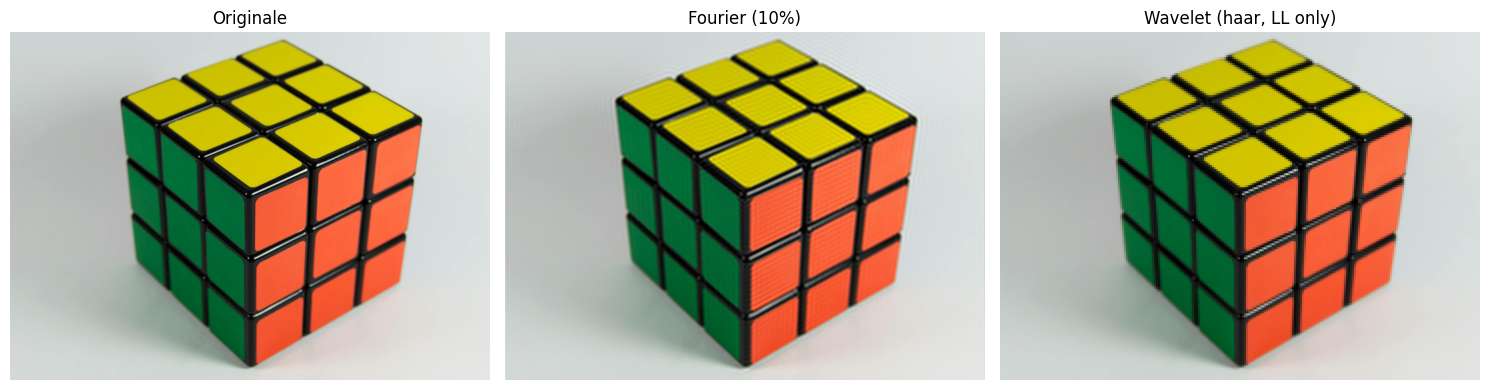

In [100]:
original = Image.open(input_path)
fourier_compressed = Image.open(COMPRESSED_DIR / "rubik_fourier_10.png")
wavelet_compressed = Image.open(COMPRESSED_DIR / "rubik_wavelet_haar_3_20_ll_only.png")

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axs, [original, fourier_compressed, wavelet_compressed],
                               ["Originale", "Fourier (10%)", "Wavelet (haar, LL only)"]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()